# HOA 7.1

## VGG16 model from sratch


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, GlobalAveragePooling2D, Dense, DepthwiseConv2D, add
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import pandas as pd

In [2]:
IMG_SIZE = (224,224)   
BATCH_SIZE = 16 
    

train_ds = tf.keras.utils.image_dataset_from_directory(
    r".\archive\FastAI_ImageNet_v2\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE) 

val_ds = tf.keras.utils.image_dataset_from_directory(
    r".\archive\FastAI_ImageNet_v2\val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 9469 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.


In [3]:
def buildvgg16(input_shape=(224, 224, 3), num_classes=10):
 model = models.Sequential(name="VGG16")


 model.add(layers.Input(shape=input_shape))
 model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1'))
 model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'))

 model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1'))
 model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'))

 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1'))
 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2'))
 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'))

 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'))
 
 
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool'))

 model.add(layers.Flatten(name='flatten'))


 model.add(layers.Dense(4096, activation='relu', name='fc1'))
 model.add(layers.Dropout(0.5, name='drop1'))

 model.add(layers.Dense(4096, activation='relu', name='fc2'))
 model.add(layers.Dropout(0.5, name='drop2'))
 model.add(layers.Dense(num_classes, activation='softmax', name='predictions'))
 return model


![Alt text for the image](conv-layers-vgg16-1024x450.jpg)


i've followed what a certain website looks like about the vgg16 similar to it and few configuration to make sure that my model will run


In [4]:
model1 = buildvgg16(input_shape=(224, 224, 3), num_classes=10)

In [5]:
model1.summary()

Model: "VGG16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)       295168

In [6]:
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,          
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          
    patience=2
)


In [8]:
history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
592/592 [==============================] - 137s 211ms/step - loss: 2.0218 - accuracy: 0.2761 - val_loss: 1.7030 - val_accuracy: 0.4303 - lr: 1.0000e-05
Epoch 2/10
592/592 [==============================] - 118s 199ms/step - loss: 1.6129 - accuracy: 0.4578 - val_loss: 1.3591 - val_accuracy: 0.5445 - lr: 1.0000e-05
Epoch 3/10
592/592 [==============================] - 117s 198ms/step - loss: 1.3503 - accuracy: 0.5521 - val_loss: 1.1945 - val_accuracy: 0.6079 - lr: 1.0000e-05
Epoch 4/10
592/592 [==============================] - 116s 195ms/step - loss: 1.1896 - accuracy: 0.6076 - val_loss: 1.1737 - val_accuracy: 0.6158 - lr: 1.0000e-05
Epoch 5/10
592/592 [==============================] - 118s 199ms/step - loss: 1.0593 - accuracy: 0.6474 - val_loss: 1.0781 - val_accuracy: 0.6535 - lr: 1.0000e-05
Epoch 6/10
592/592 [==============================] - 116s 195ms/step - loss: 0.9405 - accuracy: 0.6933 - val_loss: 0.9594 - val_accuracy: 0.6869 - lr: 1.0000e-05
Epoch 7/10
592/592 [==

## With pre trained model


In [9]:

base = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = tf.keras.applications.vgg16.preprocess_input(inputs)
x       = base(x, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(256, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)  

model2 = tf.keras.Model(inputs, outputs)



In [10]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model2.summary()  

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.__operators__.getitem (S  (None, 224, 224, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 224, 224, 3)      0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               131328

In [11]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
592/592 [==============================] - 35s 58ms/step - loss: 2.4117 - accuracy: 0.6495 - val_loss: 0.2972 - val_accuracy: 0.9220 - lr: 1.0000e-04
Epoch 2/10
592/592 [==============================] - 34s 58ms/step - loss: 0.5108 - accuracy: 0.8736 - val_loss: 0.2164 - val_accuracy: 0.9406 - lr: 1.0000e-04
Epoch 3/10
592/592 [==============================] - 35s 59ms/step - loss: 0.3327 - accuracy: 0.9094 - val_loss: 0.1824 - val_accuracy: 0.9493 - lr: 1.0000e-04
Epoch 4/10
592/592 [==============================] - 34s 58ms/step - loss: 0.2497 - accuracy: 0.9260 - val_loss: 0.1565 - val_accuracy: 0.9526 - lr: 1.0000e-04
Epoch 5/10
592/592 [==============================] - 34s 58ms/step - loss: 0.2072 - accuracy: 0.9364 - val_loss: 0.1416 - val_accuracy: 0.9559 - lr: 1.0000e-04
Epoch 6/10
592/592 [==============================] - 34s 57ms/step - loss: 0.1505 - accuracy: 0.9505 - val_loss: 0.1317 - val_accuracy: 0.9600 - lr: 1.0000e-04
Epoch 7/10
592/592 [==============

## Result and Discussion

### Accuracy Plot

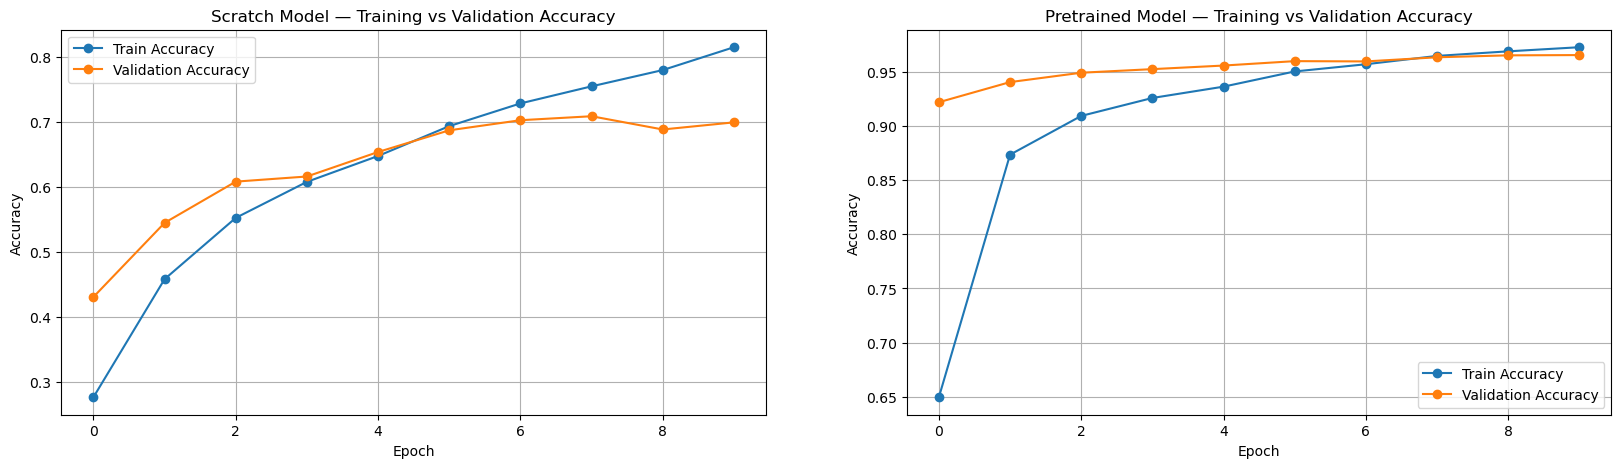

In [12]:
plt.figure(figsize=(20, 5))  # wider to fit 2 graphs

plt.subplot(1, 2, 1)  # (rows, cols, position)
plt.plot(history1.history['accuracy'],     label='Train Accuracy',     marker='o')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Scratch Model — Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) 
plt.plot(history2.history['accuracy'],     label='Train Accuracy',     marker='o')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Pretrained Model — Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
#plt.tight_layout()
plt.show()

### Confusion Matrix & Classification Report

In [ ]:
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model1.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report: VGG16 Scratch Model")
print(classification_report(y_true, y_pred, target_names=class_names))




Classification Report: VGG16 Scratch Model
              precision    recall  f1-score   support

           0       0.65      0.72      0.68       357
           1       0.66      0.37      0.47       386
           2       0.73      0.77      0.75       409
           3       0.66      0.86      0.75       395
           4       0.70      0.74      0.72       394
           5       0.64      0.80      0.71       389
           6       0.83      0.38      0.52       419
           7       0.69      0.68      0.69       399
           8       0.72      0.84      0.77       390
           9       0.77      0.86      0.81       387

    accuracy                           0.70      3925
   macro avg       0.71      0.70      0.69      3925
weighted avg       0.71      0.70      0.69      3925



In [ ]:
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model2.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report: VGG16 Pre trained Model")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report: VGG16 Pre trained Model
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       357
           1       0.92      0.96      0.94       386
           2       0.97      0.99      0.98       409
           3       0.99      0.99      0.99       395
           4       0.97      0.97      0.97       394
           5       0.96      0.95      0.96       389
           6       0.95      0.91      0.93       419
           7       0.98      0.97      0.98       399
           8       0.96      0.97      0.96       390
           9       0.99      0.99      0.99       387

    accuracy                           0.97      3925
   macro avg       0.97      0.97      0.97      3925
weighted avg       0.97      0.97      0.97      3925



### Roc Curve


Macro-Average AUC: 0.9527


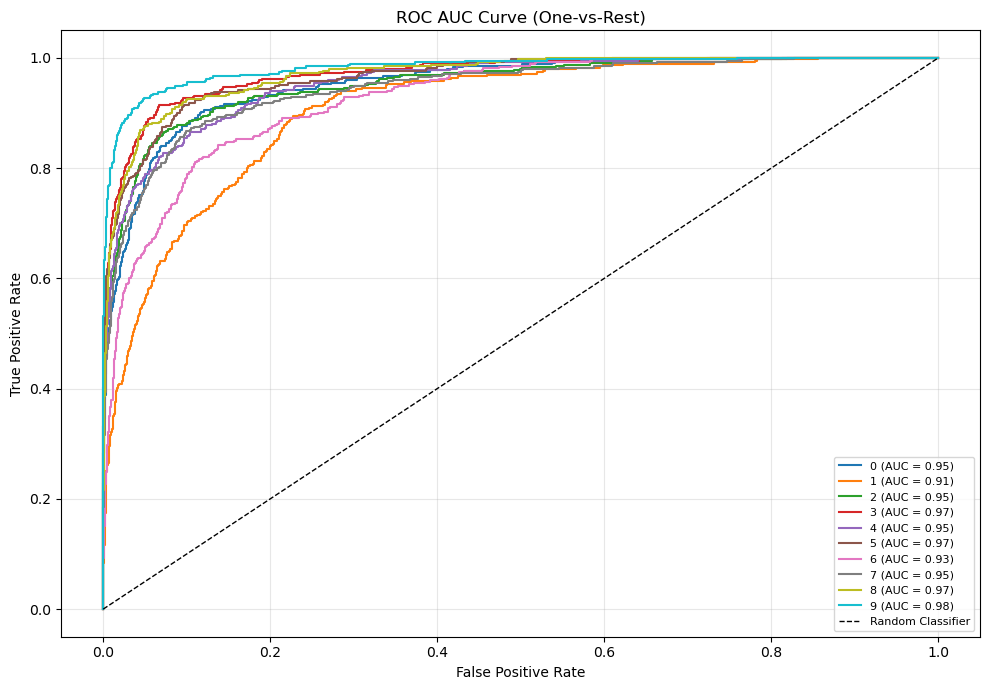

In [ ]:
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')


print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=150)
plt.show()


Macro-Average AUC: 0.9991


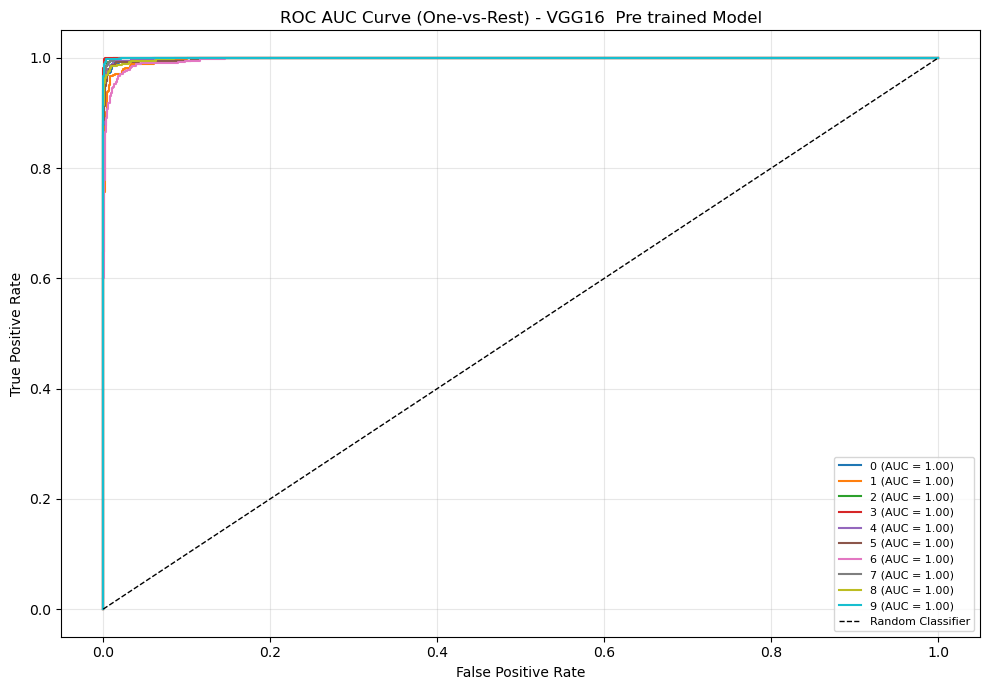

In [ ]:
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest) - VGG16  Pre trained Model')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Supplementary

## Mobilenetv2 from scratch

In [24]:
def expansion_block(x,t,filters,block_id):
    prefix = 'block_{}_'.format(block_id)
    total_filters = t*filters
    x = Conv2D(total_filters,1,padding='same',use_bias=False, name =    prefix +'expand')(x)
    x = BatchNormalization(name=prefix +'expand_bn')(x)
    x = ReLU(6,name = prefix +'expand_relu')(x)
    return x
def depthwise_block(x,stride,block_id):
    prefix = 'block_{}_'.format(block_id)
    x = DepthwiseConv2D(3,strides=(stride,stride),padding ='same', use_bias = False, name = prefix + 'depthwise_conv')(x)
    x = BatchNormalization(name=prefix +'dw_bn')(x)
    x = ReLU(6,name = prefix +'dw_relu')(x)
    return x
def projection_block(x,out_channels,block_id):
    prefix = 'block_{}_'.format(block_id)
    x = Conv2D(filters=out_channels,kernel_size = 1,   padding='same',use_bias=False,name= prefix + 'compress')(x)
    x = BatchNormalization(name=prefix +'compress_bn')(x)
    return x

In [25]:
def Bottleneck(x,t,filters, out_channels,stride,block_id):
    y = expansion_block(x,t,filters,block_id)
    y = depthwise_block(y,stride,block_id)
    y = projection_block(y, out_channels,block_id)
    if y.shape[-1]==x.shape[-1]:
       y = add([x,y])
    return y

In [26]:
def MobileNetV2(input_image = (224,224,3), n_classes=1000):
    inputs = Input(input_image) 
    x = Conv2D(32,3,strides=(2,2),padding='same', use_bias=False)(inputs)
    x = BatchNormalization(name='conv1_bn')(x)
    x = ReLU(6, name='conv1_relu')(x)
    # 17 Bottlenecks
    x = depthwise_block(x,stride=1,block_id=1)
    x = projection_block(x, out_channels=16,block_id=1)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 24, stride = 2,block_id = 2)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 24, stride = 1,block_id = 3)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 32, stride = 2,block_id = 4)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 32, stride = 1,block_id = 5)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 32, stride = 1,block_id = 6)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 2,block_id = 7)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 1,block_id = 8)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 1,block_id = 9)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 1,block_id = 10)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 96, stride = 1,block_id = 11)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 96, stride = 1,block_id = 12)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 96, stride = 1,block_id = 13)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 160, stride = 2,block_id = 14)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 160, stride = 1,block_id = 15)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 160, stride = 1,block_id = 16)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 320, stride = 1,block_id = 17)
    x = Conv2D(filters = 1280,kernel_size = 1,padding='same',use_bias=False, name = 'last_conv')(x)
    x = BatchNormalization(name='last_bn')(x)
    x = ReLU(6,name='last_relu')(x)
    x = GlobalAveragePooling2D(name='global_average_pool')(x)
    output = Dense(n_classes,activation='softmax')(x)
    model = Model(inputs, output)
    return model

In [27]:
model3 = MobileNetV2(input_image=(224,224,3), n_classes=10)

In [28]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model3.summary()  

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 112, 112, 32  864         ['input_4[0][0]']                
                                )                                                                 
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 112, 112, 32  128         ['conv2d[0][0]']                 
                                )                                                           

In [ ]:
history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
592/592 [==============================] - 36s 56ms/step - loss: 1.8999 - accuracy: 0.3319 - val_loss: 4.9114 - val_accuracy: 0.0994 - lr: 1.0000e-04
Epoch 2/10
592/592 [==============================] - 35s 60ms/step - loss: 1.5739 - accuracy: 0.4599 - val_loss: 1.5771 - val_accuracy: 0.4915 - lr: 1.0000e-04
Epoch 3/10
592/592 [==============================] - 32s 55ms/step - loss: 1.3824 - accuracy: 0.5315 - val_loss: 1.5536 - val_accuracy: 0.4976 - lr: 1.0000e-04
Epoch 4/10
592/592 [==============================] - 32s 54ms/step - loss: 1.2638 - accuracy: 0.5764 - val_loss: 1.3500 - val_accuracy: 0.5590 - lr: 1.0000e-04
Epoch 5/10
592/592 [==============================] - 32s 54ms/step - loss: 1.1449 - accuracy: 0.6170 - val_loss: 1.3397 - val_accuracy: 0.5654 - lr: 1.0000e-04
Epoch 6/10
592/592 [==============================] - 35s 59ms/step - loss: 1.0245 - accuracy: 0.6594 - val_loss: 1.1777 - val_accuracy: 0.6206 - lr: 1.0000e-04
Epoch 7/10
592/592 [==============

## Pre trained MobilenetV2 

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [44]:

base_model = tf.keras.applications.MobileNetV2(
    include_top=False, 
    weights='imagenet',           
    input_shape=(224, 224, 3) 
)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x       = base_model(x, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(256, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)  

model4 = tf.keras.Model(inputs, outputs)

In [45]:
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


In [46]:
history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
592/592 [==============================] - 19s 28ms/step - loss: 0.6430 - accuracy: 0.8095 - val_loss: 0.0945 - val_accuracy: 0.9768 - lr: 1.0000e-05
Epoch 2/10
592/592 [==============================] - 16s 27ms/step - loss: 0.1266 - accuracy: 0.9658 - val_loss: 0.0646 - val_accuracy: 0.9819 - lr: 1.0000e-05
Epoch 3/10
592/592 [==============================] - 16s 27ms/step - loss: 0.0810 - accuracy: 0.9761 - val_loss: 0.0525 - val_accuracy: 0.9855 - lr: 1.0000e-05
Epoch 4/10
592/592 [==============================] - 16s 26ms/step - loss: 0.0543 - accuracy: 0.9845 - val_loss: 0.0465 - val_accuracy: 0.9870 - lr: 1.0000e-05
Epoch 5/10
592/592 [==============================] - 15s 26ms/step - loss: 0.0369 - accuracy: 0.9897 - val_loss: 0.0462 - val_accuracy: 0.9875 - lr: 1.0000e-05
Epoch 6/10
592/592 [==============================] - 15s 25ms/step - loss: 0.0259 - accuracy: 0.9922 - val_loss: 0.0451 - val_accuracy: 0.9847 - lr: 1.0000e-05
Epoch 7/10
592/592 [==============

## Result and Discussion

### Accuracy Plot

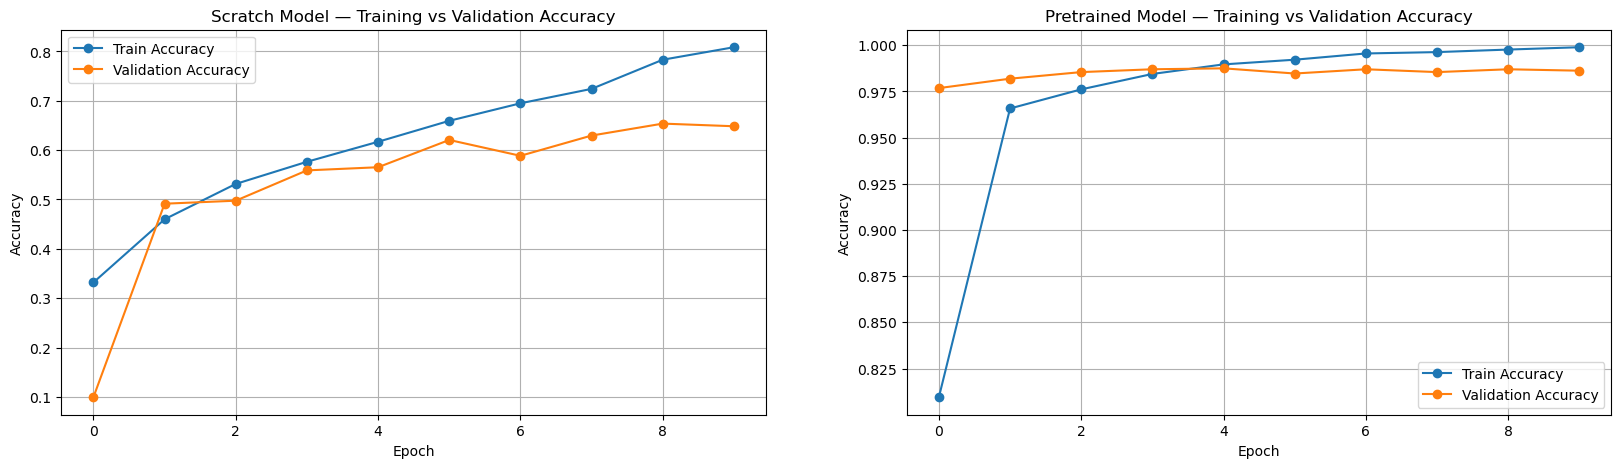

In [48]:
plt.figure(figsize=(20, 5))  

plt.subplot(1, 2, 1)  
plt.plot(history3.history['accuracy'],     label='Train Accuracy',     marker='o')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Scratch Model — Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) 
plt.plot(history4.history['accuracy'],     label='Train Accuracy',     marker='o')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Pretrained Model — Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Confusion Matrix & Classification Report

In [36]:
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model3.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report: mobilenetv2 Scratch Model")
print(classification_report(y_true, y_pred, target_names=class_names))




Classification Report: mobilenetv2 Scratch Model
              precision    recall  f1-score   support

           0       0.68      0.61      0.64       357
           1       0.49      0.35      0.41       386
           2       0.72      0.72      0.72       409
           3       0.67      0.70      0.69       395
           4       0.63      0.68      0.65       394
           5       0.79      0.57      0.66       389
           6       0.53      0.68      0.60       419
           7       0.62      0.66      0.64       399
           8       0.74      0.78      0.76       390
           9       0.66      0.72      0.69       387

    accuracy                           0.65      3925
   macro avg       0.65      0.65      0.65      3925
weighted avg       0.65      0.65      0.65      3925



In [49]:
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model4.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report: mobilenetv2 Pre trained Model")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report: mobilenetv2 Pre trained Model
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       357
           1       0.96      0.98      0.97       386
           2       0.99      0.99      0.99       409
           3       1.00      1.00      1.00       395
           4       0.99      0.98      0.99       394
           5       0.99      0.98      0.99       389
           6       0.98      0.98      0.98       419
           7       0.99      0.99      0.99       399
           8       0.97      0.99      0.98       390
           9       1.00      0.99      1.00       387

    accuracy                           0.99      3925
   macro avg       0.99      0.99      0.99      3925
weighted avg       0.99      0.99      0.99      3925



### Roc Curve


Macro-Average AUC: 0.9336


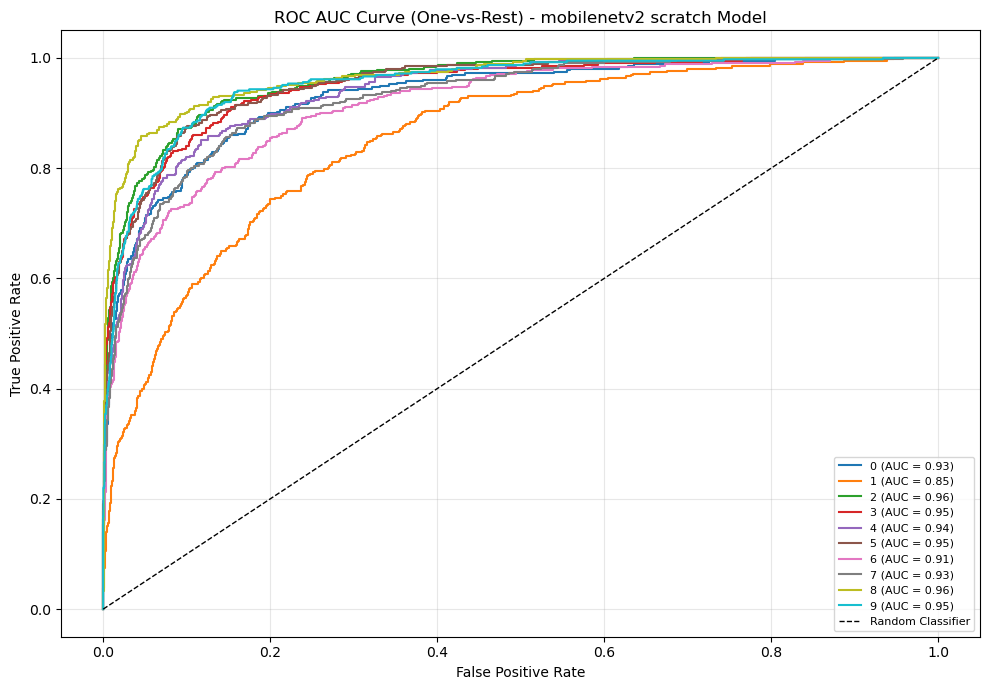

In [ ]:
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')


print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest) - mobilenetv2 scratch Model')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Macro-Average AUC: 0.9999


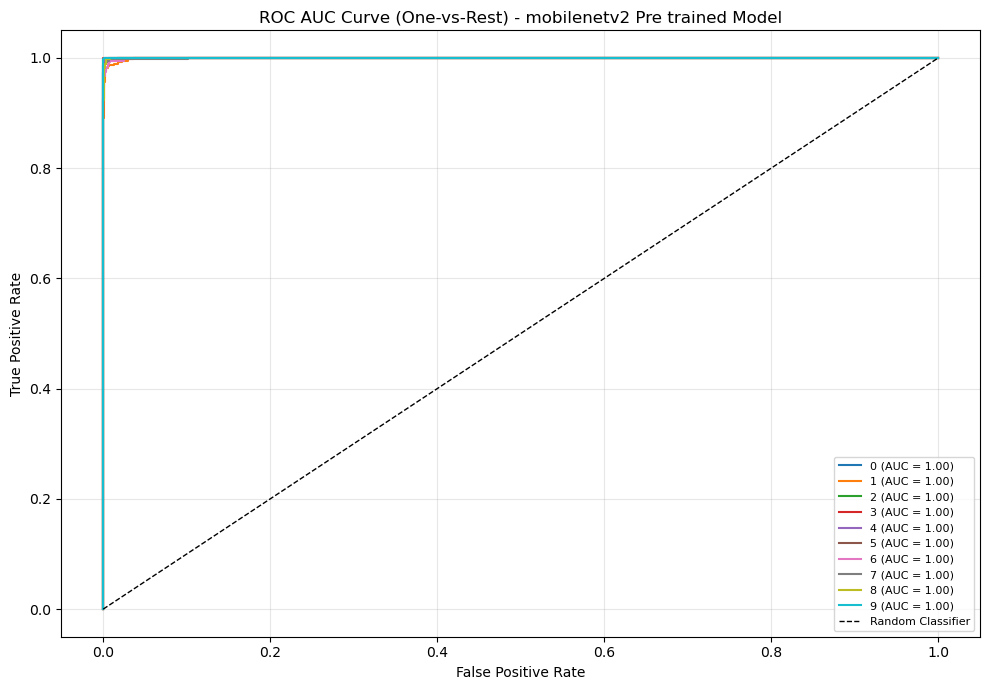

In [50]:
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest) - mobilenetv2 Pre trained Model')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()